# TMDPDF Plots

Card-driven notebook for plotting the TMDPDF in `b` space and `k_T` space.

The active parameterization and parameter values come from `Cards/<fit_name>.jl`.
The Julia NP file is inferred from the card's `NP_name` by replacing `.cl` with `.jl` under `TMDs/NP Parameterizations Julia`.

This follows the same card-first logic as `TMDs/predict.ipynb` and uses `TMDs/Grids/initialization.jl` to load the grid-based TMD inputs selected by the card's `table_name`.

The default plots are arranged in a MAP-style presentation: fixed `Q`, several `x` values, and final 3D surfaces in `(x, b)` and `(x, k_T)`.

In [1]:
from julia.api import Julia
from julia import Main

import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from tqdm import tqdm

Configuration

In [2]:
fit_name = "BroadBump42LogGaussAlpha1NoLambda2"
if_grid = True

map_plot_flavor = 'u'
map_x_values = [1e-3, 1e-2, 1e-1]
map_Q_values = [2.0, 10.0]

b_plot_min = 1e-3
b_plot_max = 8.0
n_b_plot = 180

kt_plot_min = 0.0
kt_plot_max = 2
n_kt_plot = 120

surface_Q = 4.75
surface_x_min = 1e-3
surface_x_max = 0.99
n_surface_x = 50
surface_kt_min = 0.0
surface_kt_max = 2
n_surface_kt = 20

surface_b_min = 0.05
surface_b_max = 4.0
n_surface_b = 40

surface_z_min = 0.0
surface_z_max = 1.0
n_surface_z = 20

Load Card And Julia TMD Pieces

In [3]:
TMD_root = Path.cwd().resolve()
if not (TMD_root / 'predict.ipynb').exists():
    if (TMD_root / 'TMDs' / 'predict.ipynb').exists():
        TMD_root = (TMD_root / 'TMDs').resolve()
    else:
        raise FileNotFoundError('Run this notebook from TMDs/, or launch it from the repo root so TMDs/predict.ipynb is discoverable.')

repo_root = TMD_root.parent

def include(name):
    path = (repo_root / name).resolve()
    Main.eval(f'include(raw"{path}")')

include(f"Cards/{fit_name}.jl")

param_names = [str(x) for x in Main.eval('collect(fieldnames(Params_Struct))')]
initial_params = np.asarray(Main.initial_params, dtype=float)
Main.param_names = list(param_names)

def Push_Params(params):
    lines = []
    for name, val in zip(param_names, params):
        lines.append(f"global NP_{name} = Float32({float(val)})")
    Main.eval("\n".join(lines))

params = initial_params.copy()
Push_Params(params)

active_table_name = str(Main.table_name)
np_cl_name = str(Main.NP_name)
np_julia_name = Path(np_cl_name).with_suffix('.jl').name
np_julia_path = TMD_root / 'NP Parameterizations Julia' / np_julia_name

if not np_julia_path.exists():
    raise FileNotFoundError(
        f'No Julia NP file found for {np_cl_name}. Expected {np_julia_path.name} in TMDs/NP Parameterizations Julia.'
    )

Main.if_grid = bool(if_grid)

try:
    Main.FastGK
except Exception:
    Main.eval('module FastGK end')

try:
    Main.eval('b0')
except Exception:
    Main.eval('const b0 = 1.1229189')

include('TMDs/Grids/initialization.jl')
include(f"TMDs/NP Parameterizations Julia/{np_julia_name}")
Push_Params(params)
include('TMDs/TMDPDFs/TMDPDFN.jl')

display(pd.DataFrame({
    'param': param_names,
    'value': params,
} ))

print('fit_name =', fit_name, '\n')
print('NP_name =', np_cl_name, '\n')
print('Julia NP file =', np_julia_name, '\n')
print('table_name =', active_table_name)

,param,value
0,lambda1,0.043757
1,lambda2,0.977418
2,lambda3,-1.960660
3,logx0,-4.992170
4,sigx,0.717326
5,amp,-0.338498
6,BNP,1.455523
7,c0,0.071789
8,c1,0.025831


fit_name = BroadBump42LogGaussAlpha1NoLambda2 

NP_name = NP-BroadBump42LogGaussAlpha1NoLambda2.cl 

Julia NP file = NP-BroadBump42LogGaussAlpha1NoLambda2.jl 

table_name = MSHT20N3LO-MC-4-2


Evaluate MAP-Style Slices

In [4]:
FLAVORS = ['u', 'ub', 'd', 'db', 's', 'sb', 'c', 'cb', 'b', 'bb']
FLAVOR_INDEX = {name: i for i, name in enumerate(FLAVORS)}
plot_flavor_idx = FLAVOR_INDEX[map_plot_flavor]

def as_array(julia_tuple):
    return np.asarray(julia_tuple, dtype=float)

def eval_component_b(x_value, Q_value, b_value):
    vals = as_array(Main.TMDPDF_func(b=float(b_value), x=float(x_value), Q=float(Q_value)))
    return float(x_value * vals[plot_flavor_idx])

def eval_component_kt(x_value, Q_value, kt_value):
    vals = as_array(Main.TMDPDF_kt_func(kt=float(kt_value), x=float(x_value), Q=float(Q_value)))
    return float(x_value * vals[plot_flavor_idx])

In [5]:
b_plot = np.linspace(b_plot_min, b_plot_max, n_b_plot)
kt_plot = np.linspace(kt_plot_min, kt_plot_max, n_kt_plot)

b_curves = {}
kt_curves = {}

for Q_value in map_Q_values:
    b_curves[Q_value] = {}
    kt_curves[Q_value] = {}
    for x_value in map_x_values:
        b_curves[Q_value][x_value] = np.array([
            eval_component_b(x_value, Q_value, b_value)
            for b_value in tqdm(b_plot, leave=False, desc=f'b: Q={Q_value:g}, x={x_value:g}')
        ])
        kt_curves[Q_value][x_value] = np.array([
            eval_component_kt(x_value, Q_value, kt_value)
            for kt_value in tqdm(kt_plot, leave=False, desc=f'kT: Q={Q_value:g}, x={x_value:g}')
        ])

surface_x = np.geomspace(surface_x_min, surface_x_max, n_surface_x)
surface_kt = np.linspace(surface_kt_min, surface_kt_max, n_surface_kt)
surface_b = np.linspace(surface_b_min, surface_b_max, n_surface_b)
surface_values = np.vstack([
    np.array([
        eval_component_kt(x_value, surface_Q, kt_value)
        for kt_value in surface_kt
    ])
    for x_value in tqdm(surface_x, desc='3D surface')
])
surface_b_values = np.vstack([
    np.array([
        eval_component_b(x_value, surface_Q, b_value)
        for b_value in surface_b
    ])
    for x_value in tqdm(surface_x, desc='3D b-surface')
])

3D b-surface: 100%|██████████| 50/50 [00:00<00:00, 157.70it/s]


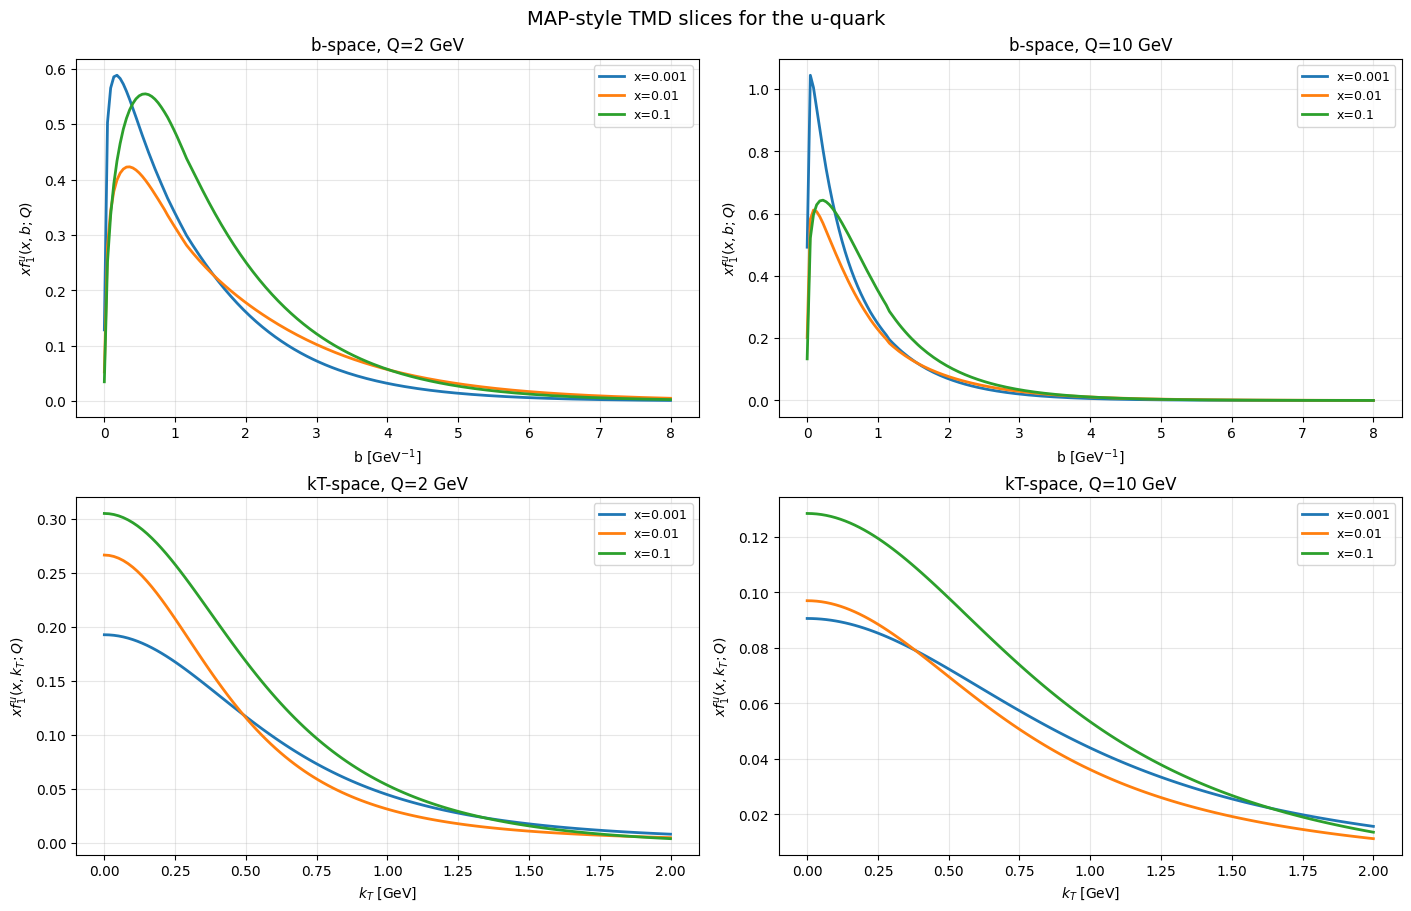

In [6]:
fig, axes = plt.subplots(2, len(map_Q_values), figsize=(7 * len(map_Q_values), 9), constrained_layout=True)

if len(map_Q_values) == 1:
    axes = np.asarray(axes).reshape(2, 1)

for col, Q_value in enumerate(map_Q_values):
    ax_b = axes[0, col]
    ax_k = axes[1, col]

    for x_value in map_x_values:
        label = f'x={x_value:g}'
        ax_b.plot(b_plot, b_curves[Q_value][x_value], linewidth=2, label=label)
        ax_k.plot(kt_plot, kt_curves[Q_value][x_value], linewidth=2, label=label)

    ax_b.set_xlabel('b [GeV$^{-1}$]')
    ax_b.set_ylabel(rf'$x f_1^{{{map_plot_flavor}}}(x,b; Q)$')
    ax_b.set_title(f'b-space, Q={Q_value:g} GeV')
    ax_b.grid(True, alpha=0.3)
    ax_b.legend(fontsize=9)

    ax_k.set_xlabel(r'$k_T$ [GeV]')
    ax_k.set_ylabel(rf'$x f_1^{{{map_plot_flavor}}}(x,k_T; Q)$')
    ax_k.set_title(f'kT-space, Q={Q_value:g} GeV')
    ax_k.grid(True, alpha=0.3)
    ax_k.legend(fontsize=9)

fig.suptitle(f'MAP-style TMD slices for the {map_plot_flavor}-quark', fontsize=14)
plt.show()

In [7]:
summary = []
b_idx = np.argmin(np.abs(b_plot - 0.5))
kt_idx = np.argmin(np.abs(kt_plot - 1.0))

for Q_value in map_Q_values:
    for x_value in map_x_values:
        summary.append({
            'flavor': map_plot_flavor,
            'Q': Q_value,
            'x': x_value,
            'x_f(b=0.5)': b_curves[Q_value][x_value][b_idx],
            'x_f(kT=1.0)': kt_curves[Q_value][x_value][kt_idx],
        })

pd.DataFrame(summary)

,flavor,Q,x,x_f(b=0.5),x_f(kT=1.0)
0,u,2.0,0.001,0.495987,0.043977
1,u,2.0,0.010,0.412108,0.030686
2,u,2.0,0.100,0.551073,0.052389
3,u,10.0,0.001,0.512976,0.043559
4,u,10.0,0.010,0.426224,0.035735
5,u,10.0,0.100,0.569949,0.052770


3D Surface

C:\Users\congyue zhang\AppData\Local\Temp\ipykernel_28120\636370876.py:64: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


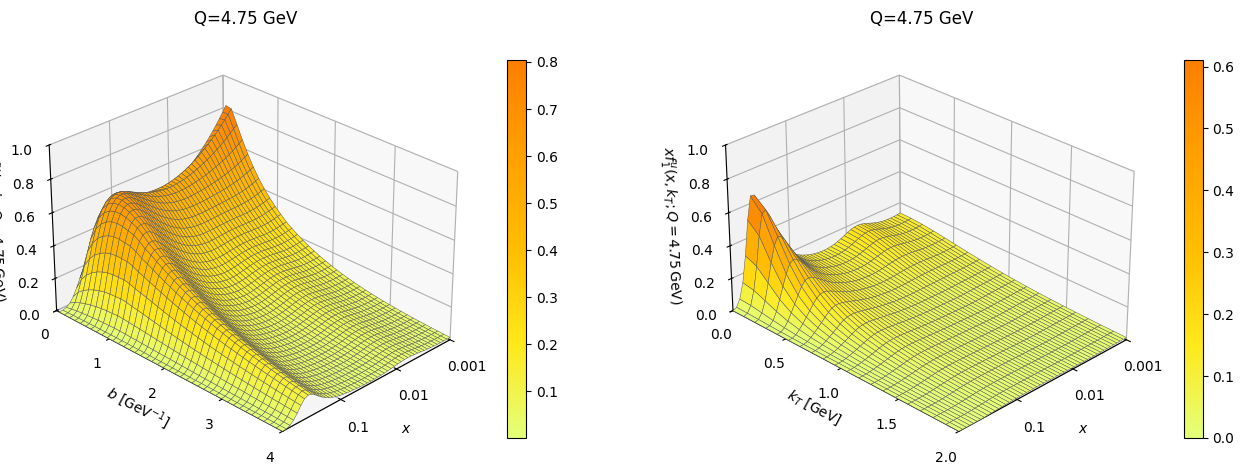

In [9]:
surface_logx = np.log10(surface_x)
Xkt, Ksurf = np.meshgrid(surface_logx, surface_kt, indexing='ij')
Xb, Bsurf = np.meshgrid(surface_logx, surface_b, indexing='ij')

surface_kt_plot = np.clip(surface_values, surface_z_min, surface_z_max)
surface_b_plot = np.clip(surface_b_values, surface_z_min, surface_z_max)

def style_surface(ax, ylabel, zlabel, title, y_ticks, y_limits):
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(ylabel)
    ax.set_zlabel(zlabel)
    ax.set_xticks(np.log10(map_x_values))
    ax.set_xticklabels([f'{x_value:g}' for x_value in map_x_values])
    ax.set_xlim(np.log10(surface_x_min), np.log10(surface_x_max))
    ax.set_ylim(*y_limits)
    ax.set_yticks(y_ticks)
    ax.set_zlim(surface_z_min, surface_z_max)
    ax.view_init(elev=28, azim=45)
    ax.set_box_aspect((1.15, 1.55, 0.9))
    ax.set_title(title)

fig = plt.figure(figsize=(16, 7))
ax_b = fig.add_subplot(121, projection='3d')
ax_kt = fig.add_subplot(122, projection='3d')

surf_b = ax_b.plot_surface(
    Xb,
    Bsurf,
    surface_b_plot,
    cmap='Wistia',
    linewidth=0.35,
    edgecolor='0.35',
    antialiased=True,
)
style_surface(
    ax_b,
    r'$b$ [GeV$^{-1}$]',
    rf'$x f_1^{{{map_plot_flavor}}}(x,b; Q={surface_Q:g}\,\mathrm{{GeV}})$',
    f'Q={surface_Q:g} GeV',
    np.arange(0, surface_b_max + 0.1, 1.0),
    (surface_b_min, surface_b_max),
)

surf_kt = ax_kt.plot_surface(
    Xkt,
    Ksurf,
    surface_kt_plot,
    cmap='Wistia',
    linewidth=0.35,
    edgecolor='0.35',
    antialiased=True,
)
style_surface(
    ax_kt,
    r'$k_T$ [GeV]',
    rf'$x f_1^{{{map_plot_flavor}}}(x,k_T; Q={surface_Q:g}\,\mathrm{{GeV}})$',
    f'Q={surface_Q:g} GeV',
    np.arange(0, surface_kt_max + 0.1, 0.5),
    (surface_kt_min, surface_kt_max),
)

fig.colorbar(surf_b, ax=ax_b, shrink=0.7, pad=0.08)
fig.colorbar(surf_kt, ax=ax_kt, shrink=0.7, pad=0.08)
plt.tight_layout()
plt.show()